In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-last-version")
version = project.version(10)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 36.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pv-last-version--10 in yolov8:: 100%|██████████| 6680/6680 [00:08<00:00, 756.24it/s] 


In [ ]:
import os
import yaml
from glob import glob

yaml_path = "/content/pv-last-version--10/data.yaml"
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

old_classes = data_yaml["names"]

print("📌 الكلاسات القديمة:")
for i, c in enumerate(old_classes):
    print(i, c)

mapping = {
    # group examined
    "Examined": "examined",
    "examined": "examined",

    # group crack
    "Crack": "crack",
    "Backsheet Scratch": "crack",
    "Branch Cracks": "crack",
    "Branch crack": "crack",
    "Micro crack": "crack",
    "MicroCrack": "crack",
    "Microcracks": "crack",
    "crack": "crack",

    # group low_cell
    "ShortCircuitString": "low_cell",
    "ShortCircuitCell -LowPowerCell-": "low_cell",
    "Dark Cell": "low_cell",
    "DarkSpot": "low_cell",
    "black_cell": "low_cell",
    "black_edge": "low_cell",
    "low_cell": "low_cell",

    # group isolated_area
    "Isolated area": "isolated_area",
    "Isolation Area": "isolated_area",

    # group othererror
    "OtherError": "othererror",
    "Fingerline Interruption": "othererror",
    "break": "othererror",
    "Shunt": "othererror",
    "Scratch": "othererror",
    "Poor Ribbon Soldering": "othererror",
    "Backsheet Scratch": "othererror",

    # contamination stays same
    "Contamination": "contamination",
    "contamination": "contamination",
}

new_classes = sorted(set(mapping.values()))
new_class_to_id = {c: i for i, c in enumerate(new_classes)}

print("\n📌 الكلاسات الجديدة:")
print(new_class_to_id)


label_dirs = [
    "/content/pv-last-version--10/train/labels",
    "/content/pv-last-version--10/valid/labels",
    "/content/pv-last-version--10/test/labels"
]

for label_dir in label_dirs:
    if not os.path.exists(label_dir):
        continue
    for file in glob(os.path.join(label_dir, "*.txt")):
        new_lines = []
        with open(file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                old_id = int(parts[0])
                old_class_name = old_classes[old_id]

                if old_class_name not in mapping:
                    continue

                new_class_name = mapping[old_class_name]
                new_id = new_class_to_id[new_class_name]

                parts[0] = str(new_id)
                new_lines.append(" ".join(parts))


        with open(file, "w") as f:
            f.write("\n".join(new_lines))


data_yaml["names"] = new_classes

new_yaml_path = "/content/pv-last-version--10/data_merged.yaml"
with open(new_yaml_path, "w") as f:
    yaml.dump(data_yaml, f)

print("\n✅ خلصت! data.yaml الجديد موجود هنا:", new_yaml_path)


📌 الكلاسات القديمة:
0 0 Examined
1 1 ShortCircuitString
2 2 ShortCircuitCell -LowPowerCell-
3 3 Crack
4 4 MicroCrack
5 5 OtherError
6 Backsheet Scratch
7 Branch Cracks
8 Branch crack
9 Contamination
10 Dark Cell
11 DarkSpot
12 Examined
13 Fingerline Interruption
14 Isolated area
15 Isolation Area
16 Micro crack
17 MicroCrack
18 Microcracks
19 Poor Ribbon Soldering
20 Scratch
21 Shunt
22 black_cell
23 black_edge
24 break
25 contamination
26 crack
27 examined
28 low_cell

📌 الكلاسات الجديدة:
{'contamination': 0, 'crack': 1, 'examined': 2, 'isolated_area': 3, 'low_cell': 4, 'othererror': 5}

✅ خلصت! data.yaml الجديد موجود هنا: /content/pv-last-version--10/data_merged.yaml


In [ ]:
import os

# paths
paths = ["/content/pv-last-version--10/test/labels", "/content/pv-last-version--10/train/labels", "/content/pv-last-version--10/valid/labels"]

# define valid IDs (0 to 5 since nc=6)
valid_ids = set(range(6))
found_invalid = False

for p in paths:
    if not os.path.exists(p):
        print(f"⚠️ Path not found: {p}")
        continue

    for file in os.listdir(p):
        if file.endswith(".txt"):
            with open(os.path.join(p, file), "r") as f:
                for line_num, line in enumerate(f, 1):
                    parts = line.strip().split()
                    if not parts:  # skip empty lines
                        continue
                    class_id = int(parts[0])
                    if class_id not in valid_ids:
                        print(f"❌ Invalid ID {class_id} in {p}/{file}, line {line_num}")
                        found_invalid = True

if not found_invalid:
    print("✅ All class IDs are valid (0–5) in train/valid/test labels.")


✅ All class IDs are valid (0–5) in train/valid/test labels.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
project_path = "/content/drive/MyDrive/training_result(6 classes)"
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 42.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo-training/v8m-custom3/weights/best.pt")

results = model.train(
    data="/content/pv-last-version--10/data_merged.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project=project_path,
    name="pv_defect_model"
)


Ultralytics 8.3.179 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pv-last-version--10/data_merged.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=pv_defect_model2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

 18                  -1  2   1846272  ultralytics.nn.modules.block.C2f             [576, 384, 2]                 
 19                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384, 384, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  2   4207104  ultralytics.nn.modules.block.C2f             [960, 576, 2]                 
 22        [15, 18, 21]  1   3779170  ultralytics.nn.modules.head.Detect           [6, [192, 384, 576]]          
Model summary: 169 layers, 25,859,794 parameters, 25,859,778 gradients, 79.1 GFLOPs

Transferred 469/475 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 68.8±20.9 MB/s, size: 324.3 KB)


train: Scanning /content/pv-last-version--10/train/labels... 2718 images, 1922 backgrounds, 0 corrupt: 100%|██████████| 2718/2718 [00:05<00:00, 459.01it/s]

...

      50/50       7.5G     0.7742       0.76     0.8787         63        640: 100%|██████████| 170/170 [01:33<00:00,  1.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:03<00:00,  2.49it/s]

                   all        266       3354      0.634      0.562      0.545        0.4



50 epochs completed in 1.429 hours.
Optimizer stripped from /content/drive/MyDrive/training_result(6 classes)/pv_defect_model2/weights/last.pt, 52.0MB
Optimizer stripped from /content/drive/MyDrive/training_result(6 classes)/pv_defect_model2/weights/best.pt, 52.0MB

Validating /content/drive/MyDrive/training_result(6 classes)/pv_defect_model2/weights/best.pt...
Ultralytics 8.3.179 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:05<00:00,  1.67it/s]


                   all        266       3354      0.614      0.573      0.554      0.404
         contamination         13        474      0.484      0.546      0.521      0.311
                 crack         82        974      0.689      0.533      0.547      0.314
              examined        125        125      0.852          1      0.968      0.966
         isolated_area         39        298      0.642      0.228      0.275      0.151
              low_cell         57       1434      0.552      0.738      0.688      0.521
            othererror          7         49      0.467      0.394      0.327      0.159
Speed: 0.3ms preprocess, 7.8ms inference, 0.0ms loss, 4.7ms postprocess per image
Results saved to /content/drive/MyDrive/training_result(6 classes)/pv_defect_model2



image 1/1 /content/2.jpg: 640x576 15 cracks, 1 examined, 2 isolated_areas, 1 low_cell, 37.1ms
Speed: 4.4ms preprocess, 37.1ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 576)
Class: crack, Conf: 0.93, Position: Row 3, Column 2
Class: crack, Conf: 0.92, Position: Row 3, Column 3
Class: crack, Conf: 0.91, Position: Row 2, Column 2
Class: crack, Conf: 0.89, Position: Row 2, Column 3
Class: crack, Conf: 0.89, Position: Row 2, Column 3
Class: crack, Conf: 0.88, Position: Row 3, Column 3
Class: crack, Conf: 0.88, Position: Row 3, Column 2
Class: crack, Conf: 0.87, Position: Row 1, Column 2
Class: crack, Conf: 0.87, Position: Row 3, Column 1
Class: crack, Conf: 0.86, Position: Row 3, Column 2
Class: crack, Conf: 0.86, Position: Row 2, Column 1
Class: crack, Conf: 0.85, Position: Row 3, Column 3
Class: crack, Conf: 0.85, Position: Row 2, Column 3
Class: crack, Conf: 0.83, Position: Row 3, Column 3
Class: crack, Conf: 0.82, Position: Row 3, Column 2
Class: examined, Conf: 0.77,

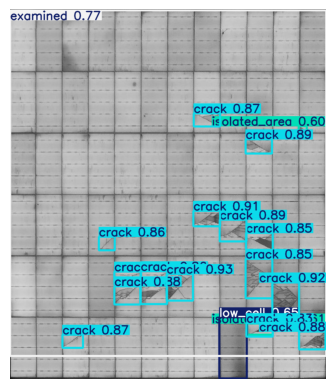

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("/content/drive/MyDrive/training_result(6 classes)/pv_defect_model2/weights/best.pt")


img_path = "/content/2.jpg"


img = cv2.imread(img_path)
h, w, _ = img.shape

results = model(img_path, conf=0.5)


for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])


        x1, y1, x2, y2 = box.xyxy[0].tolist()


        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2

        grid_rows, grid_cols = 3, 3
        row = int((y_center / h) * grid_rows) + 1
        col = int((x_center / w) * grid_cols) + 1

        print(f"Class: {model.names[cls]}, Conf: {conf:.2f}, Position: Row {row}, Column {col}")

    plotted = r.plot()
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12



image 1/1 /content/16image--2-_jpg.rf.a898ce8cb4b7d96f7bcc272c3f8a21e8.jpg: 352x640 2 cracks, 1 isolation_area, 55.2ms
Speed: 14.5ms preprocess, 55.2ms inference, 356.3ms postprocess per image at shape (1, 3, 352, 640)


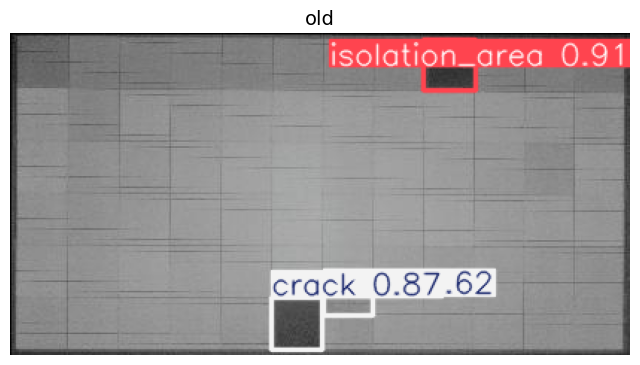


image 1/1 /content/16image--2-_jpg.rf.a898ce8cb4b7d96f7bcc272c3f8a21e8.jpg: 352x640 2 isolated_areas, 25.6ms
Speed: 1.6ms preprocess, 25.6ms inference, 1.9ms postprocess per image at shape (1, 3, 352, 640)


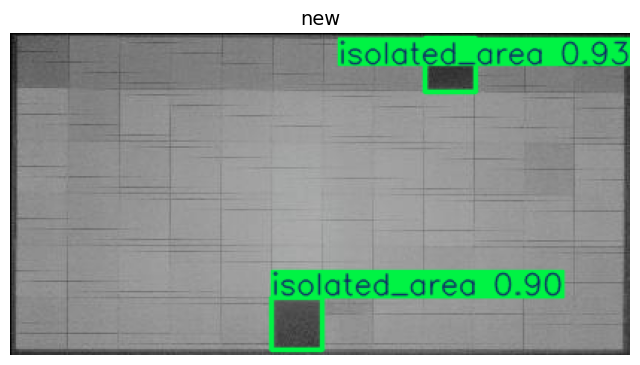

In [ ]:

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


model = YOLO("/content/drive/MyDrive/yolo-training(old)/v8m-custom3/weights/best.pt")


img_path = "/content/16image--2-_jpg.rf.a898ce8cb4b7d96f7bcc272c3f8a21e8.jpg"


results = model(img_path, conf=0.5)


for r in results:

    plotted = r.plot()

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("old", fontsize=14)
    plt.axis("off")
    plt.show()


model = YOLO("/content/drive/MyDrive/yolo-training(new)/v8m-custom/weights/best.pt")




results = model(img_path, conf=0.5)


for r in results:

    plotted = r.plot()


    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("new", fontsize=14)
    plt.axis("off")
    plt.show()


# **train the new model again**

In [ ]:
model = YOLO("/content/drive/MyDrive/yolo-training(new)/v8m-custom/weights/best.pt")
results = model.train(
    data="/content/pv-last-version--10/data_merged.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project=project_path,
    name="pv_defect_model",
    pretrained=True
)


Ultralytics 8.3.179 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pv-last-version--10/data_merged.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo-training(new)/v8m-custom/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=pv_defect_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

Overriding model.yaml nc=12 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

  9                  -1  1    831168  ultralytics.nn.modules.block.SPPF            [576, 576, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  2   1993728  ultralytics.nn.modules.block.C2f             [960, 384, 2]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  2    517632  ultralytics.nn.modules.block.C2f             [576, 192, 2]                 
 16                  -1  1    332160  ultralytics.nn.modules.conv.Conv             [192, 192, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]  

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 67.5±19.5 MB/s, size: 324.3 KB)


train: Scanning /content/pv-last-version--10/train/labels... 2718 images, 1922 backgrounds, 0 corrupt: 100%|██████████| 2718/2718 [00:05<00:00, 526.03it/s]

...

      50/50      7.51G      0.693     0.4995       0.85         63        640: 100%|██████████| 170/170 [01:33<00:00,  1.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:03<00:00,  2.83it/s]

                   all        266       3354      0.716      0.538      0.563      0.405



50 epochs completed in 1.414 hours.
Optimizer stripped from /content/drive/MyDrive/train the new model again/pv_defect_model/weights/last.pt, 52.0MB
Optimizer stripped from /content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt, 52.0MB

Validating /content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt...
Ultralytics 8.3.179 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:06<00:00,  1.32it/s]


                   all        266       3354      0.717      0.549      0.574      0.411
         contamination         13        474      0.532      0.545      0.533      0.294
                 crack         82        974      0.772       0.55      0.604      0.359
              examined        125        125      0.857      0.992      0.967      0.967
         isolated_area         39        298      0.654      0.302       0.33      0.183
              low_cell         57       1434      0.648      0.616      0.611      0.471
            othererror          7         49      0.838      0.286      0.399      0.194
Speed: 0.4ms preprocess, 8.0ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to /content/drive/MyDrive/train the new model again/pv_defect_model



image 1/1 /content/2.jpg: 640x576 15 cracks, 4 isolated_areas, 1 low_cell, 47.7ms
Speed: 3.2ms preprocess, 47.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 576)


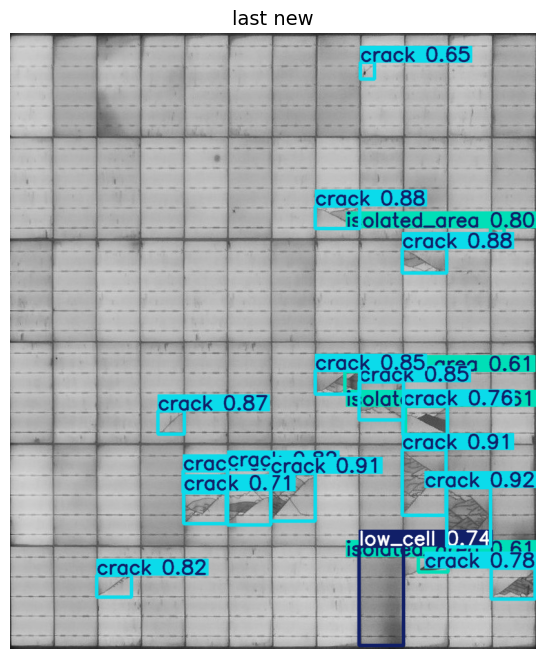


image 1/1 /content/2.jpg: 640x576 16 cracks, 4 isolated_areas, 36.6ms
Speed: 4.2ms preprocess, 36.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 576)


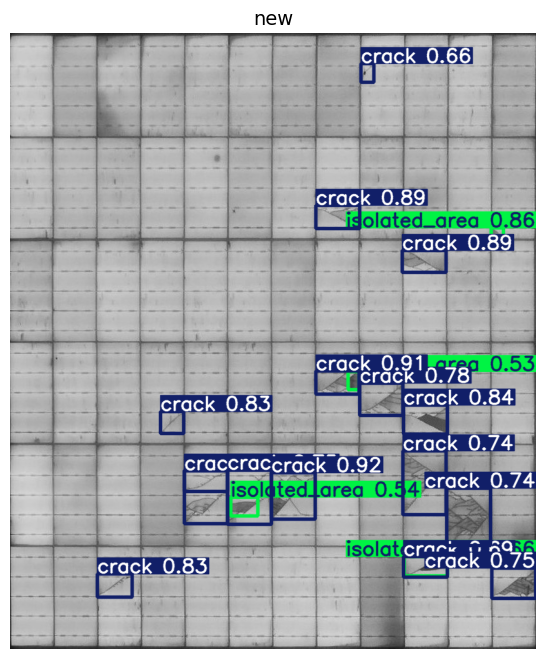

In [ ]:

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


model = YOLO("/content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt")


img_path = "/content/2.jpg"


results = model(img_path, conf=0.5)


for r in results:

    plotted = r.plot()


    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("last new", fontsize=14)
    plt.axis("off")
    plt.show()

model = YOLO("/content/drive/MyDrive/yolo-training(new)/v8m-custom/weights/best.pt")




results = model(img_path, conf=0.5)


for r in results:

    plotted = r.plot()

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("new", fontsize=14)
    plt.axis("off")
    plt.show()


اكتب عدد الصفوف في الخلية الشمسية: 6
اكتب عدد الأعمدة في الخلية الشمسية: 12

image 1/1 /content/2.jpg: 640x576 15 cracks, 4 isolated_areas, 1 low_cell, 36.6ms
Speed: 3.7ms preprocess, 36.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 576)
Defect: crack, Conf: 0.92, row 5 column 11
Defect: crack, Conf: 0.91, row 5 column 10
Defect: crack, Conf: 0.91, row 5 column 7
Defect: crack, Conf: 0.88, row 3 column 10
Defect: crack, Conf: 0.88, row 2 column 8
Defect: crack, Conf: 0.87, row 4 column 4
Defect: crack, Conf: 0.85, row 4 column 8
Defect: crack, Conf: 0.85, row 4 column 9
Defect: crack, Conf: 0.82, row 5 column 6
Defect: crack, Conf: 0.82, row 6 column 3
Defect: isolated_area, Conf: 0.80, row 2 column 12
Defect: crack, Conf: 0.78, row 6 column 12
Defect: crack, Conf: 0.76, row 4 column 10
Defect: low_cell, Conf: 0.74, row 6 column 9
Defect: crack, Conf: 0.71, row 5 column 5
Defect: crack, Conf: 0.65, row 1 column 9
Defect: isolated_area, Conf: 0.61, row 4 column 10
Defe

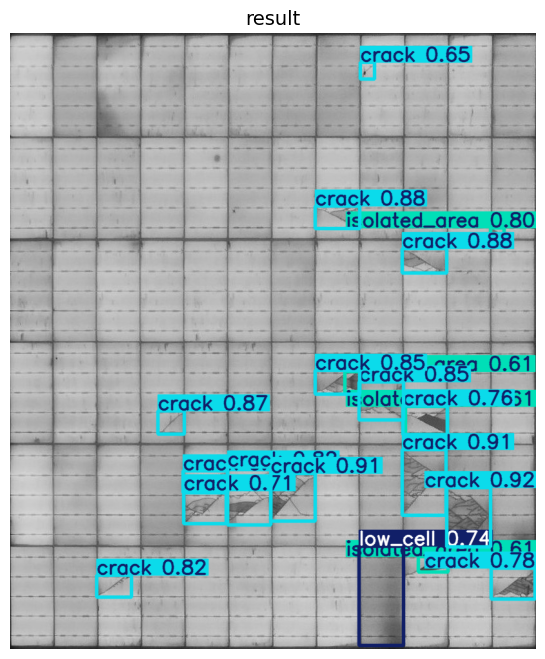

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


model = YOLO("/content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt")


img_path = "/content/2.jpg"


img = cv2.imread(img_path)
h, w, _ = img.shape


grid_rows = int(input("number of rows "))
grid_cols = int(input("number of columns "))
results = model(img_path, conf=0.5)


for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()


        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2

        row = int((y_center / h) * grid_rows) + 1
        col = int((x_center / w) * grid_cols) + 1

        print(f"Defect: {model.names[cls]}, Conf: {conf:.2f}, row {row} column {col}")

    plotted = r.plot()
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("result", fontsize=14)
    plt.axis("off")
    plt.show()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
اكتب عدد الصفوف في الخلية الشمسية: 24
اكتب عدد الأعمدة في الخلية الشمسية: 6

image 1/1 /content/100%.jpg: 640x416 1 examined, 35 low_cells, 1077.1ms
Speed: 12.2ms preprocess, 1077.1ms inference, 28.2ms postprocess per image at shape (1, 3, 640, 416)
Defect: examined, Conf: 0.98, row 13 column 4
Defect: low_cell, Conf: 0.90, row 17 column 1
Defect: low_cell, Conf: 0.90, row 5 column 5
Defect: low_cell, Conf: 0.88, row 18 column 6
Defect: low_cell, Conf: 0.88, row 1 column 4
Defect: low_cell, Conf: 0.87, row 23 column 6
Defect: low_cell, Conf: 0.87, row 21 column 4
Defect: low_cell, Conf: 0.87, row 1 column 2
Defect: low_cell, Conf: 0.87, row 18 column 1
Defect: low_cell, Conf: 0.87

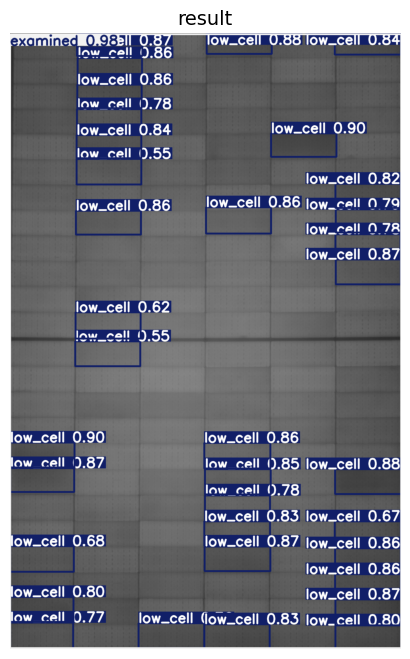

اكتب عدد الصفوف في الخلية الشمسية: 24
اكتب عدد الأعمدة في الخلية الشمسية: 6

image 1/1 /content/0.1_ISC_2.JPG: 640x384 1 examined, 35 low_cells, 855.5ms
Speed: 3.4ms preprocess, 855.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)
Defect: examined, Conf: 0.97, row 13 column 4
Defect: low_cell, Conf: 0.90, row 16 column 6
Defect: low_cell, Conf: 0.90, row 8 column 5
Defect: low_cell, Conf: 0.89, row 18 column 4
Defect: low_cell, Conf: 0.89, row 15 column 2
Defect: low_cell, Conf: 0.88, row 7 column 3
Defect: low_cell, Conf: 0.88, row 16 column 4
Defect: low_cell, Conf: 0.87, row 19 column 6
Defect: low_cell, Conf: 0.87, row 9 column 4
Defect: low_cell, Conf: 0.87, row 20 column 2
Defect: low_cell, Conf: 0.87, row 7 column 5
Defect: low_cell, Conf: 0.86, row 18 column 6
Defect: low_cell, Conf: 0.86, row 18 column 4
Defect: low_cell, Conf: 0.86, row 9 column 5
Defect: low_cell, Conf: 0.86, row 9 column 5
Defect: low_cell, Conf: 0.85, row 18 column 2
Defect: low_cell, C

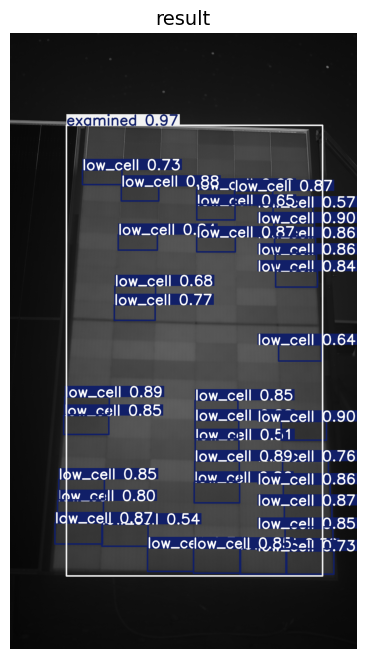

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("/content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt")

img_path = "/content/100%.jpg"

img = cv2.imread(img_path)
h, w, _ = img.shape
grid_rows = int(input("number of rows "))
grid_cols = int(input("number of columns "))
results = model(img_path, conf=0.5)

for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])


        x1, y1, x2, y2 = box.xyxy[0].tolist()


        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2


        row = int((y_center / h) * grid_rows) + 1
        col = int((x_center / w) * grid_cols) + 1

        print(f"Defect: {model.names[cls]}, Conf: {conf:.2f}, row {row} column {col}")

    plotted = r.plot()
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("result", fontsize=14)
    plt.axis("off")
    plt.show()



model = YOLO("/content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt")


img_path = "/content/0.1_ISC_2.JPG"


img = cv2.imread(img_path)
h, w, _ = img.shape
grid_rows = int(input("number of rows "))
grid_cols = int(input("number of columns "))

results = model(img_path, conf=0.5)

for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])   # class index
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()


        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2

        row = int((y_center / h) * grid_rows) + 1
        col = int((x_center / w) * grid_cols) + 1

        print(f"Defect: {model.names[cls]}, Conf: {conf:.2f}, row {row} column {col}")

    plotted = r.plot()
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("result", fontsize=14)
    plt.axis("off")
    plt.show()


# **try to gave a number to low_cell**

Number of rows 6
Number of columns12

image 1/1 /content/2.jpg: 640x576 15 cracks, 4 isolated_areas, 1 low_cell, 1335.4ms
Speed: 4.0ms preprocess, 1335.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 576)
Defect: crack, Conf: 0.92, Row 5, Col 11
Defect: crack, Conf: 0.91, Row 5, Col 10
Defect: crack, Conf: 0.91, Row 5, Col 7
Defect: crack, Conf: 0.88, Row 3, Col 10
Defect: crack, Conf: 0.88, Row 2, Col 8
Defect: crack, Conf: 0.87, Row 4, Col 4
Defect: crack, Conf: 0.85, Row 4, Col 8
Defect: crack, Conf: 0.85, Row 4, Col 9
Defect: crack, Conf: 0.82, Row 5, Col 6
Defect: crack, Conf: 0.82, Row 6, Col 3
Defect: isolated_area, Conf: 0.80, Row 2, Col 12
Defect: crack, Conf: 0.78, Row 6, Col 12
Defect: crack, Conf: 0.76, Row 4, Col 10
Defect: low_cell, Conf: 0.74, Row 6, Col 9
Defect: crack, Conf: 0.71, Row 5, Col 5
Defect: crack, Conf: 0.65, Row 1, Col 9
Defect: isolated_area, Conf: 0.61, Row 4, Col 10
Defect: isolated_area, Conf: 0.61, Row 4, Col 8
Defect: isolated_area, Co

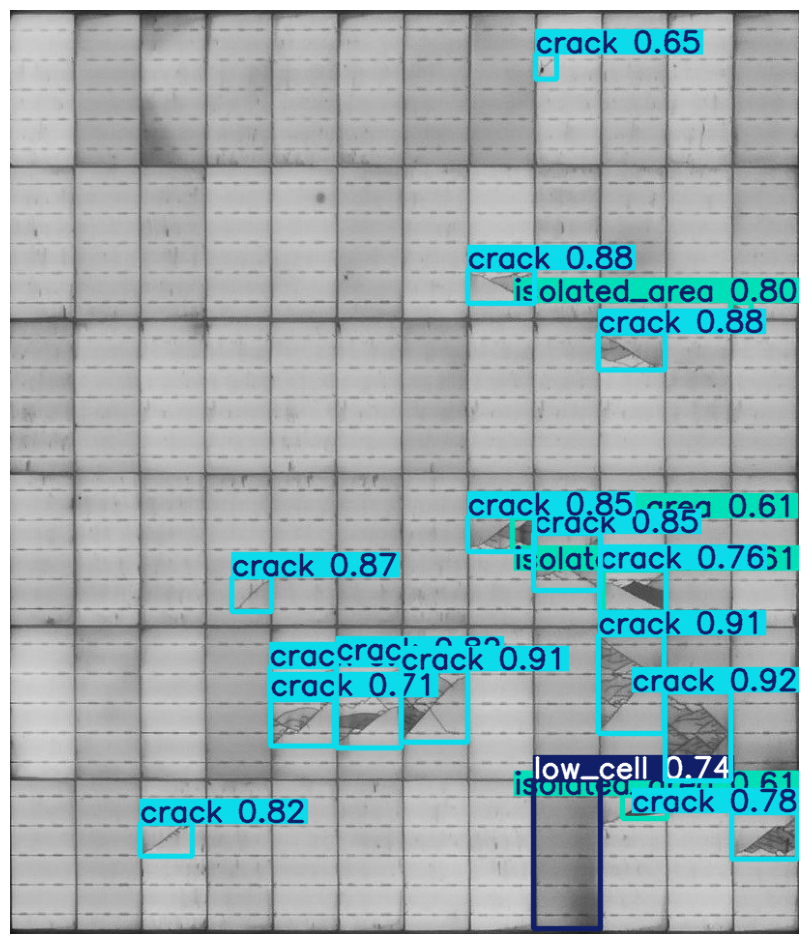

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt


model = YOLO("/content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt")


img_path = "/content/2.jpg"
img = cv2.imread(img_path)
h, w, _ = img.shape


grid_rows = int(input("Number of rows "))
grid_cols = int(input("Number of columns"))

results = model(img_path, conf=0.5)


defected_cells = set()
lowcell_data = []

for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = model.names[cls]

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        roi = img[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        mean_intensity = np.mean(gray)


        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2
        row = int((y_center / h) * grid_rows) + 1
        col = int((x_center / w) * grid_cols) + 1

        defected_cells.add((row, col))
        print(f"Defect: {label}, Conf: {conf:.2f}, Row {row}, Col {col}")

        if label == "low_cell":
            lowcell_data.append(((row, col), mean_intensity, (x1, y1, x2, y2)))

#
clean_intensities = []
cell_h, cell_w = h // grid_rows, w // grid_cols

for row in range(1, grid_rows + 1):
    for col in range(1, grid_cols + 1):
        if (row, col) not in defected_cells:
            y1, y2 = (row - 1) * cell_h, row * cell_h
            x1, x2 = (col - 1) * cell_w, col * cell_w
            roi = img[y1:y2, x1:x2]
            gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
            clean_intensities.append(np.mean(gray))


if len(clean_intensities) > 0:
    clean_ref = np.mean(clean_intensities)
else:
    clean_ref = 255

print(f"\n number of reference cells: {len(clean_intensities)}")
print(f"  (clean_ref): {clean_ref:.2f}")


for (row, col), intensity, (x1, y1, x2, y2) in lowcell_data:
    darkness = ((clean_ref - intensity) / clean_ref) * 100
    cv2.putText(img, f"{darkness:.1f}%", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    print(f"Low_cell at row {row}, col {col}: Darkness = {darkness:.2f}% "
          f"(intensity {intensity:.1f}, ref {clean_ref:.1f})")


for r in results:
    plotted = r.plot()
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


In [ ]:
import cv2
import numpy as np

def calculate_sharpness(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var

sharpness_value = calculate_sharpness("/content/2.jpg")
print("Sharpness (Laplacian Variance):", sharpness_value)


Sharpness (Laplacian Variance): 309.3589246949077


In [ ]:
def sharpness_sobel(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
    return np.mean(gradient_magnitude)

sharpness_val = sharpness_sobel("/content/2.jpg")
print("Sharpness (Sobel):", sharpness_val)


Sharpness (Sobel): 46.95132266016243


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Number of rows 24
Number of columns6

image 1/1 /content/ISC_1.JPG: 640x384 1 examined, 5 low_cells, 125.3ms
Speed: 13.8ms preprocess, 125.3ms inference, 389.6ms postprocess per image at shape (1, 3, 640, 384)
Defect: examined, Conf: 0.97, Row 12, Col 3
Defect: low_cell, Conf: 0.92, Row 8, Col 2
Defect: low_cell, Conf: 0.85, Row 9, Col 2
Defect: low_cell, Conf: 0.68, Row 14, Col 2
Defect: low_cell, Conf: 0.59, Row 16, Col 2
Defect: low_cell, Conf: 0.57, Row 16, Col 2

 number of reference cells: 139
  (clean_ref): 52.78
Low_cell at row 8, col 2: Darkness = -55.70% (intensity 82.2, ref 52.8)
Low_cell at row 9, col 2: Darkness = -70.52% (intensity 90.0, ref 52.8)
Low_cell at row 14,

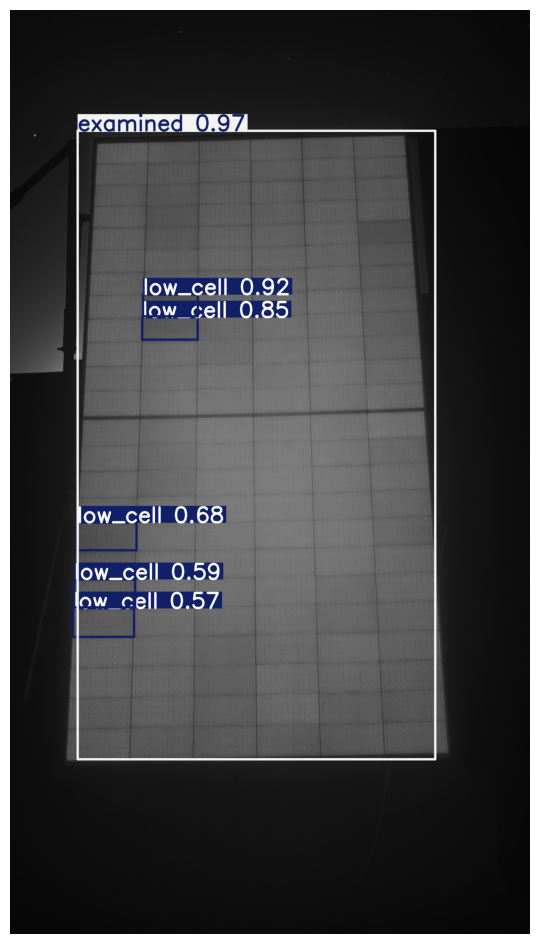

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt


model = YOLO("/content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt")


img_path = "/content/ISC_1.JPG"
img = cv2.imread(img_path)
h, w, _ = img.shape


grid_rows = int(input("Number of rows "))
grid_cols = int(input("Number of columns"))

results = model(img_path, conf=0.5)


defected_cells = set()
lowcell_data = []

for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = model.names[cls]

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        roi = img[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        mean_intensity = np.mean(gray)


        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2
        row = int((y_center / h) * grid_rows) + 1
        col = int((x_center / w) * grid_cols) + 1

        defected_cells.add((row, col))
        print(f"Defect: {label}, Conf: {conf:.2f}, Row {row}, Col {col}")

        if label == "low_cell":
            lowcell_data.append(((row, col), mean_intensity, (x1, y1, x2, y2)))


clean_intensities = []
cell_h, cell_w = h // grid_rows, w // grid_cols

for row in range(1, grid_rows + 1):
    for col in range(1, grid_cols + 1):
        if (row, col) not in defected_cells:
            y1, y2 = (row - 1) * cell_h, row * cell_h
            x1, x2 = (col - 1) * cell_w, col * cell_w
            roi = img[y1:y2, x1:x2]
            gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
            clean_intensities.append(np.mean(gray))


if len(clean_intensities) > 0:
    clean_ref = np.mean(clean_intensities)
else:
    clean_ref = 255

print(f"\n number of reference cells: {len(clean_intensities)}")
print(f"  (clean_ref): {clean_ref:.2f}")


for (row, col), intensity, (x1, y1, x2, y2) in lowcell_data:
    darkness = ((clean_ref - intensity) / clean_ref) * 100
    cv2.putText(img, f"{darkness:.1f}%", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    print(f"Low_cell at row {row}, col {col}: Darkness = {darkness:.2f}% "
          f"(intensity {intensity:.1f}, ref {clean_ref:.1f})")


for r in results:
    plotted = r.plot()
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


Number of rows: 24
Number of columns: 6

image 1/1 /content/photo_2025-09-14_00-20-05.jpg: 640x384 1 examined, 5 low_cells, 109.5ms
Speed: 15.2ms preprocess, 109.5ms inference, 356.8ms postprocess per image at shape (1, 3, 640, 384)
Defect: examined, Conf: 0.97, Row 12, Col 3
Defect: low_cell, Conf: 0.91, Row 5, Col 4
Defect: low_cell, Conf: 0.90, Row 4, Col 4
Defect: low_cell, Conf: 0.86, Row 4, Col 4
Defect: low_cell, Conf: 0.76, Row 12, Col 2
Defect: low_cell, Conf: 0.59, Row 6, Col 4

Reference cell = (13, 3), with intensity = 118.25
Low_cell at row 5, col 4: Darkness = 42.45% (intensity 68.0, ref 118.3)
Low_cell at row 4, col 4: Darkness = 46.78% (intensity 62.9, ref 118.3)
Low_cell at row 4, col 4: Darkness = 40.11% (intensity 70.8, ref 118.3)
Low_cell at row 12, col 2: Darkness = 31.97% (intensity 80.4, ref 118.3)
Low_cell at row 6, col 4: Darkness = 32.73% (intensity 79.6, ref 118.3)


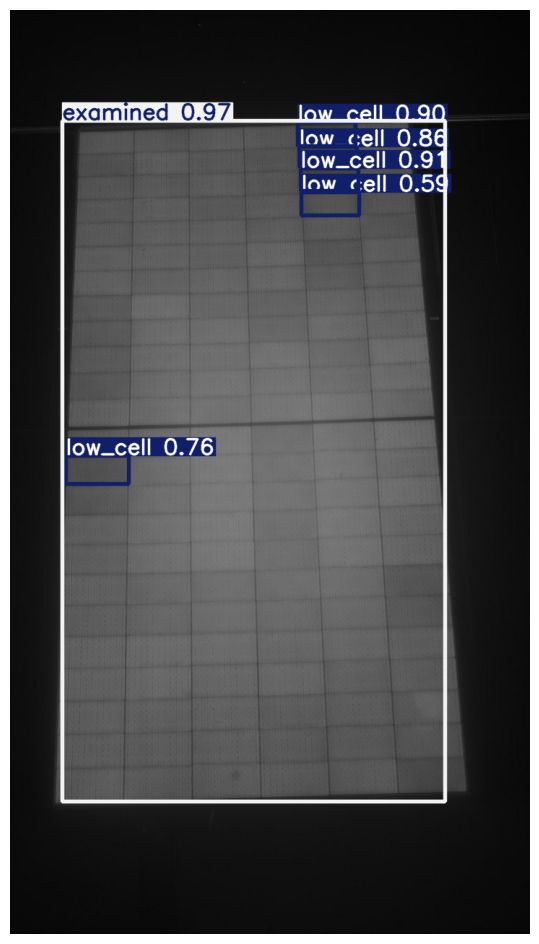

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt


model = YOLO("/content/drive/MyDrive/train the new model again/pv_defect_model/weights/best.pt")

img_path = "/content/photo_2025-09-14_00-20-05.jpg"
img = cv2.imread(img_path)
h, w, _ = img.shape


grid_rows = int(input("Number of rows: "))
grid_cols = int(input("Number of columns: "))


results = model(img_path, conf=0.5)

defected_cells = set()
lowcell_data = []

for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = model.names[cls]


        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        roi = img[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        mean_intensity = np.mean(gray)

        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2
        row = int((y_center / h) * grid_rows) + 1
        col = int((x_center / w) * grid_cols) + 1

        defected_cells.add((row, col))
        print(f"Defect: {label}, Conf: {conf:.2f}, Row {row}, Col {col}")

        if label == "low_cell":
            lowcell_data.append(((row, col), mean_intensity, (x1, y1, x2, y2)))



cell_h, cell_w = h // grid_rows, w // grid_cols
cell_intensities = []

for row in range(1, grid_rows + 1):
    for col in range(1, grid_cols + 1):
        y1, y2 = (row - 1) * cell_h, row * cell_h
        x1, x2 = (col - 1) * cell_w, col * cell_w
        roi = img[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        mean_val = np.mean(gray)
        cell_intensities.append(((row, col), mean_val))

if len(cell_intensities) > 0:
    ref_cell, clean_ref = max(cell_intensities, key=lambda x: x[1])
else:
    clean_ref = 255
    ref_cell = (None, None)

print(f"\nReference cell = {ref_cell}, with intensity = {clean_ref:.2f}")

for (row, col), intensity, (x1, y1, x2, y2) in lowcell_data:
    darkness = ((clean_ref - intensity) / clean_ref) * 100
    cv2.putText(img, f"{darkness:.1f}%", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    print(f"Low_cell at row {row}, col {col}: Darkness = {darkness:.2f}% "
          f"(intensity {intensity:.1f}, ref {clean_ref:.1f})")


for r in results:
    plotted = r.plot()
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.5 MB/s eta 0:00:00


# **fine tunning to model detect cells**

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="I9vohnBPTTnfP90JG5ML")
project = rf.workspace("omnia-lp9xt").project("crop-lo56h")
version = project.version(4)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 95.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to crop-4 in yolov8:: 100%|██████████| 276/276 [00:00<00:00, 7769.63it/s]


In [ ]:

!pip install ultralytics --upgrade -q


from ultralytics import YOLO


model = YOLO("/content/drive/MyDrive/model_detect_cells/best1.pt")

results = model.train(
    data="/content/crop-4/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    optimizer="Adam",
    patience=20,
)




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crop-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, 

In [ ]:
!pip install ultralytics --upgrade -q

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("/content/runs/detect/train/weights/best.pt")


img_path = "/content/ISC_1.JPG"

results = model.predict(img_path, conf=0.25, show=False)

results[0].save(filename="result.jpg")


img = cv2.imread("result.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train/weights/best.pt'